# Titanic project

<m>

## 1. Data wrangling & exploratory data analysis

<m>

### 1.1 Import and read data

<m>

In [ ]:
import pandas as pd
import numpy as np
import janitor as janitor
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from scipy import stats
import statsmodels.api as sm
from statsmodels.api import OLS
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
import psycopg2
import mysql.connector
import re
import ast
import openpyxl
import pyarrow
from fuzzywuzzy import fuzz,process
import geopandas as gpd
import warnings as warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth',None)
old_money_style = {
    "axes.facecolor": "#f8f5f0", 
    "axes.edgecolor": "#4a4a4a",      
    "axes.labelcolor": "#2e2e2e",     
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    
    "figure.facecolor": "#f8f5f0",     
    "figure.edgecolor": "#f8f5f0",
    
    "font.family": "serif",           
    "font.size": 12,
    
    "grid.color": "#d9d6d2",           
    "grid.linestyle": "--",
    "grid.alpha": 0.6,
    
    "lines.linewidth": 2,
    "lines.color": "#2e2e2e",         
    
    "xtick.color": "#2e2e2e",
    "ytick.color": "#2e2e2e",
    
    "legend.facecolor": "#f8f5f0",
    "legend.edgecolor": "#4a4a4a",
    "legend.fontsize": 12
}
plt.style.use(old_money_style)
%matplotlib inline

C:\Users\yousi\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\yousi\AppData\Roaming\Python\Python314\site-packages\sweetviz\graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
df=pd.read_csv("Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<m>

### 1.2 Understanding data

<m>

In [4]:
report=sv.analyze(df)
report.show_html('Profiling report.html')

In [5]:
#report=ydp.ProfileReport(df)
#report.to_file("profiling report.html")

In [6]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.index

RangeIndex(start=0, stop=891, step=1)

In [10]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
print(df.duplicated().sum())

0


<m>

### 1.3 Preparing data

<m>

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [14]:
df['Family_Size']=df['SibSp']+df['Parch']

In [15]:
df=df[['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 
       #'SibSp', #'Parch', 
       'Ticket', 'Fare','Family_Size'#'Cabin',#'Embarked'
      ]]

In [16]:
new_order=['PassengerId','Name','Sex','Age','Family_Size','Pclass','Ticket','Fare','Survived']

In [17]:
df=df[new_order]

In [18]:
df['Fare']=round(df['Fare'],2)

In [19]:
df.rename(columns={'Sex':'Gender'},inplace=True)

<m>

### 1.3.1 Dealing with nulls

<m>

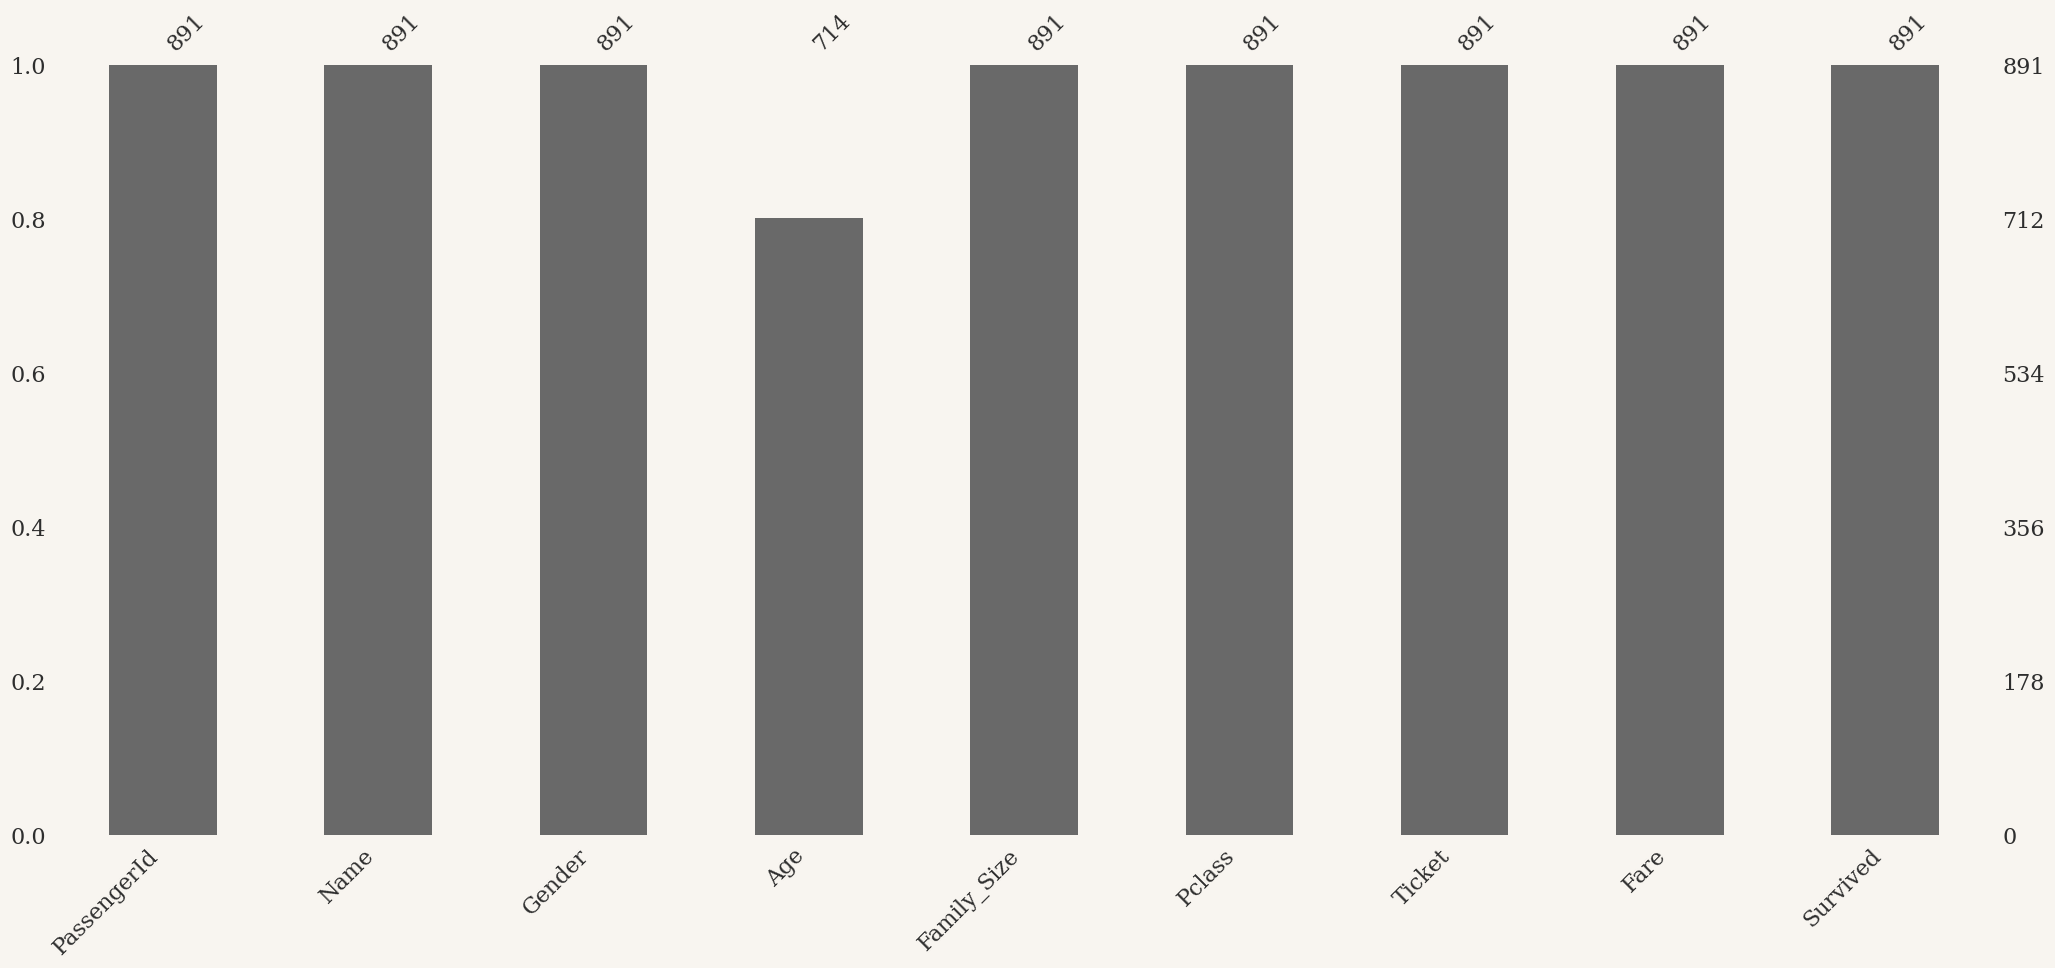

In [20]:
msno.bar(df)
plt.show()

In [21]:
df.isnull().sum()

PassengerId      0
Name             0
Gender           0
Age            177
Family_Size      0
Pclass           0
Ticket           0
Fare             0
Survived         0
dtype: int64

In [22]:
df.query('Age.isnull()').head()

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Survived
5,6,"Moran, Mr. James",male,NaN,0,3,330877,8.46,0
17,18,"Williams, Mr. Charles Eugene",male,NaN,0,2,244373,13.00,1
19,20,"Masselmani, Mrs. Fatima",female,NaN,0,3,2649,7.22,1
26,27,"Emir, Mr. Farred Chehab",male,NaN,0,3,2631,7.22,0
28,29,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,3,330959,7.88,1


In [23]:
df['Age'] = df.groupby(['Pclass', 'Gender'])['Age'].transform(lambda x: x.fillna(round(x.median())))

##### Filling the nulls in age column with the with the median age

In [24]:
df.query('Age < 1')

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Survived
78,79,"Caldwell, Master. Alden Gates",male,0.83,2,2,248738,29.00,1
305,306,"Allison, Master. Hudson Trevor",male,0.92,3,1,113781,151.55,1
469,470,"Baclini, Miss. Helene Barbara",female,0.75,3,3,2666,19.26,1
644,645,"Baclini, Miss. Eugenie",female,0.75,3,3,2666,19.26,1
755,756,"Hamalainen, Master. Viljo",male,0.67,2,2,250649,14.50,1
803,804,"Thomas, Master. Assad Alexander",male,0.42,1,3,2625,8.52,1
831,832,"Richards, Master. George Sibley",male,0.83,2,2,29106,18.75,1


In [25]:
df['Age'] = df['Age'].apply(lambda x: round((x * 12) / 100, 2) if x < 1 else x)

In [26]:
df.query('Age < 1')

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Survived
78,79,"Caldwell, Master. Alden Gates",male,0.10,2,2,248738,29.00,1
305,306,"Allison, Master. Hudson Trevor",male,0.11,3,1,113781,151.55,1
469,470,"Baclini, Miss. Helene Barbara",female,0.09,3,3,2666,19.26,1
644,645,"Baclini, Miss. Eugenie",female,0.09,3,3,2666,19.26,1
755,756,"Hamalainen, Master. Viljo",male,0.08,2,2,250649,14.50,1
803,804,"Thomas, Master. Assad Alexander",male,0.05,1,3,2625,8.52,1
831,832,"Richards, Master. George Sibley",male,0.10,2,2,29106,18.75,1


In [27]:
df.query('Fare.isnull()')

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Survived


In [28]:
avg_fare=round(df['Fare'].mean(),2)
print(avg_fare)

32.2


In [29]:
df['Fare']=df['Fare'].fillna(avg_fare)

In [30]:
df.isnull().sum()

PassengerId    0
Name           0
Gender         0
Age            0
Family_Size    0
Pclass         0
Ticket         0
Fare           0
Survived       0
dtype: int64

<m>

### 1.3.2 Dealing with outliers

##### Z-score - IQR

<M>

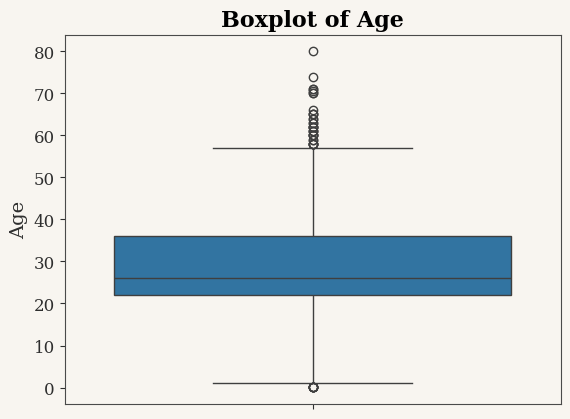

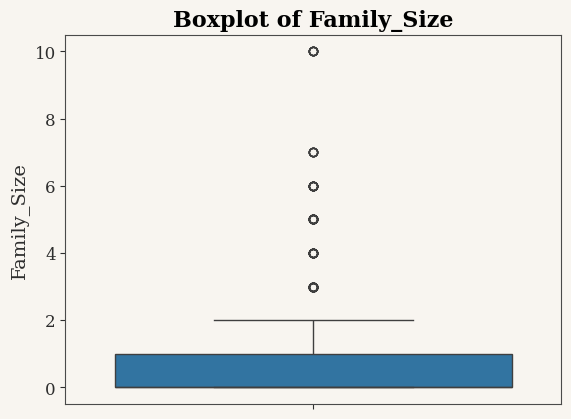

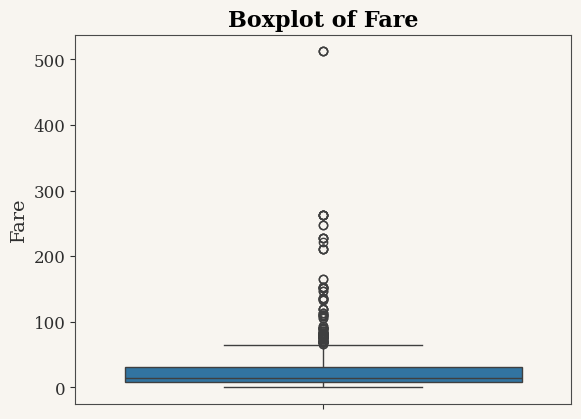

In [31]:
for column in ['Age', 'Family_Size','Fare']:
    sns.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

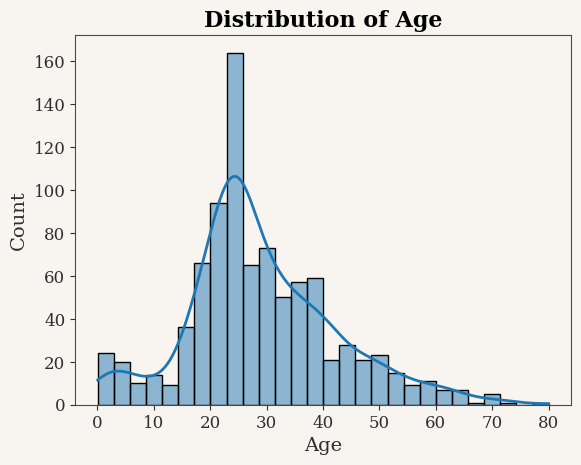

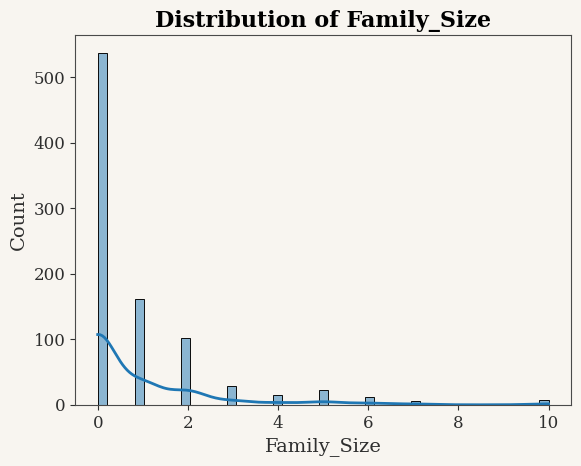

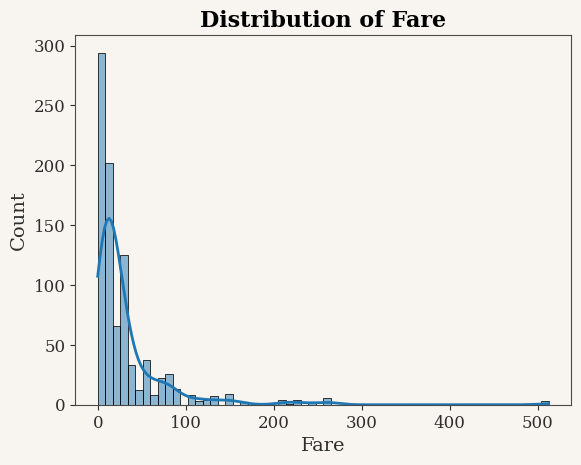

In [32]:
for column in ['Age', 'Family_Size','Fare']:
    sns.histplot(df[column],kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

In [33]:
df[['Age', 'Family_Size','Fare']].skew()

Age            0.526419
Family_Size    2.727441
Fare           4.787324
dtype: float64

<m>

##### Z-Score

<m>

In [34]:
def detect_outliers_z_score_values(df,column):
    upper_limit = df[column].mean()+3*df[column].std()
    lower_limit = df[column].mean()-3*df[column].std()
    print(f'Upper_Limit : {upper_limit}\nLower_Limit : {lower_limit}')

In [35]:
def detect_outliers_z_score_sample(df,column):
    upper_limit = df[column].mean()+3*df[column].std()
    lower_limit = df[column].mean()-3*df[column].std()
    return df[(df[column]>upper_limit) | (df[column]<lower_limit)].head()

In [36]:
def detect_outliers_z_score_population(df,column):
    upper_limit = df[column].mean()+3*df[column].std()
    lower_limit = df[column].mean()-3*df[column].std()
    return df[(df[column]>upper_limit) | (df[column]<lower_limit)]

##### Age Z-Score

In [37]:
detect_outliers_z_score_values(df,'Age')

Upper_Limit : 69.03801195202108
Lower_Limit : -10.776238663581115


In [38]:
detect_outliers_z_score_sample(df,'Age')

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Survived
96,97,"Goldschmidt, Mr. George B",male,71.0,0,1,PC 17754,34.65,0
116,117,"Connors, Mr. Patrick",male,70.5,0,3,370369,7.75,0
493,494,"Artagaveytia, Mr. Ramon",male,71.0,0,1,PC 17609,49.50,0
630,631,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,1,27042,30.00,1
672,673,"Mitchell, Mr. Henry Michael",male,70.0,0,2,C.A. 24580,10.50,0


In [39]:
print(df['Age'].max())

80.0


In [40]:
print(df['Age'].min())

0.05


##### The age column does not exhibit any outliers, as the distribution falls within an expected and reasonable range

<m>

##### IQR

<m>

In [41]:
def iqr_outliers_values(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    return upper_bond,lower_bond

In [42]:
def detect_outliers_iqr_sample(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    return df[(df[column]>upper_bond) | (df[column]<lower_bond)].head()

In [43]:
def detect_outliers_iqr_population(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    upper_bond=q3+1.5*iqr
    lower_bond=q1-1.5*iqr
    return df[(df[column]>upper_bond) | (df[column]<lower_bond)]

##### Fare IQR

In [44]:
upper_bond,lower_bond=iqr_outliers_values(df,'Fare')
print(f'upper bond: {upper_bond}\nlower bond: {lower_bond}')

upper bond: 65.63499999999999
lower bond: -26.724999999999998


In [45]:
detect_outliers_iqr_sample(df,'Fare')

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Survived
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,1,PC 17599,71.28,1
27,28,"Fortune, Mr. Charles Alexander",male,19.0,5,1,19950,263.00,0
31,32,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,35.0,1,1,PC 17569,146.52,1
34,35,"Meyer, Mr. Edgar Joseph",male,28.0,1,1,PC 17604,82.17,0
52,53,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,1,PC 17572,76.73,1


In [46]:
print(df['Fare'].max())

512.33


In [47]:
print(df['Fare'].min())

0.0


In [48]:
fare_pop=detect_outliers_iqr_population(df,'Fare')

In [49]:
fare_pop.sort_values(by='Fare',ascending=False).head(10)

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Survived
679,680,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,1,1,PC 17755,512.33,1
258,259,"Ward, Miss. Anna",female,35.0,0,1,PC 17755,512.33,1
737,738,"Lesurer, Mr. Gustave J",male,35.0,0,1,PC 17755,512.33,1
341,342,"Fortune, Miss. Alice Elizabeth",female,24.0,5,1,19950,263.00,1
438,439,"Fortune, Mr. Mark",male,64.0,5,1,19950,263.00,0
88,89,"Fortune, Miss. Mabel Helen",female,23.0,5,1,19950,263.00,1
27,28,"Fortune, Mr. Charles Alexander",male,19.0,5,1,19950,263.00,0
311,312,"Ryerson, Miss. Emily Borie",female,18.0,4,1,PC 17608,262.38,1
742,743,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,4,1,PC 17608,262.38,1
118,119,"Baxter, Mr. Quigg Edmond",male,24.0,1,1,PC 17558,247.52,0


##### The fare column here represents the fare of the ticket wich can be shared by a whole family so if the whole family ticket is first class
##### the fare of the ticket will be large and the zero fare may represent some of the crew or governament funded tickets

##### Family size IQR

In [50]:
upper_bond,lower_bond=iqr_outliers_values(df,'Family_Size')
print(f'upper bond: {upper_bond}\nlower bond: {lower_bond}')

upper bond: 2.5
lower bond: -1.5


In [51]:
detect_outliers_iqr_sample(df,'Family_Size')

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Survived
7,8,"Palsson, Master. Gosta Leonard",male,2.0,4,3,349909,21.08,0
13,14,"Andersson, Mr. Anders Johan",male,39.0,6,3,347082,31.28,0
16,17,"Rice, Master. Eugene",male,2.0,5,3,382652,29.12,0
24,25,"Palsson, Miss. Torborg Danira",female,8.0,4,3,349909,21.08,0
25,26,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)",female,38.0,6,3,347077,31.39,1


In [52]:
print(df['Family_Size'].max())

10


In [53]:
print(df['Family_Size'].min())

0


##### The values of the famiily size column is not ubnormal it lies within a normal range

<m>

### 1.3.3 Formatting and adding columns

<m>

##### Fare_Per_Person

In [54]:
df['Fare_Per_Person'] = df['Fare'] / df.groupby('Ticket')['Ticket'].transform('count')

In [55]:
df['Fare_Per_Person']=round(df['Fare_Per_Person'],2)

In [56]:
df.columns

Index(['PassengerId', 'Name', 'Gender', 'Age', 'Family_Size', 'Pclass',
       'Ticket', 'Fare', 'Survived', 'Fare_Per_Person'],
      dtype='str')

In [57]:
new_order2=['PassengerId', 'Name', 'Gender', 'Age', 'Family_Size', 'Pclass', 'Ticket',
       'Fare','Fare_Per_Person','Survived']

In [58]:
df=df[new_order2]

<m>

### 1.4 Understanding features

<M>

#### (Univariant analysis)

<m>

##### Distribution of features

<m>

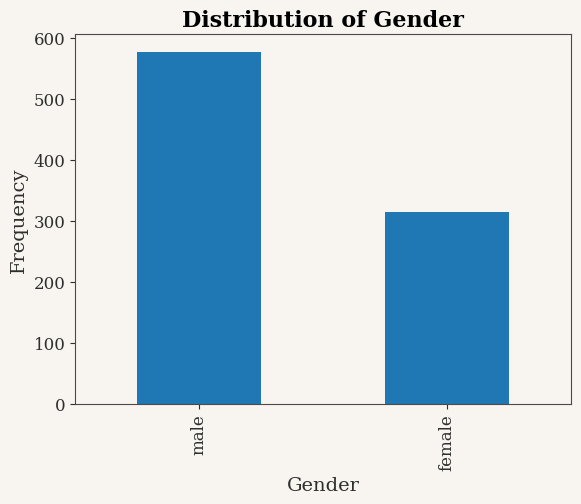

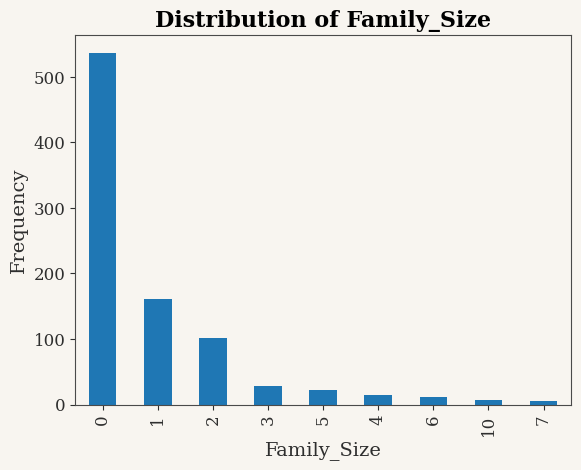

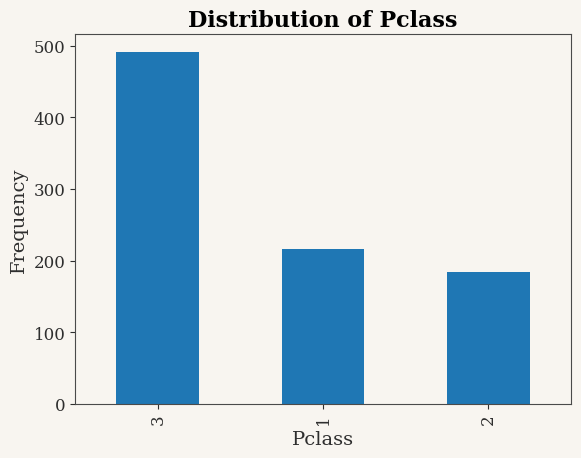

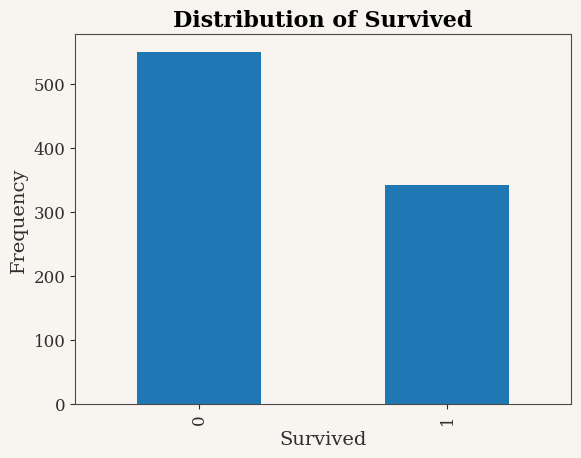

In [59]:
for column in ['Gender','Family_Size','Pclass','Survived']:
    ax=df[column].value_counts().plot(kind='bar',title=f'Distribution of {column}')
    ax.set_xlabel(f'{column}')
    ax.set_ylabel('Frequency')
    plt.show()

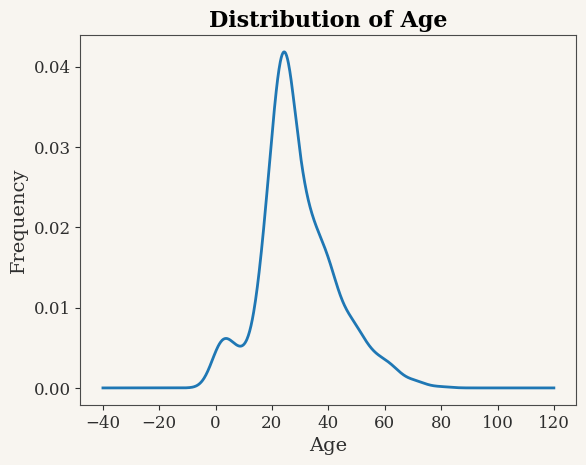

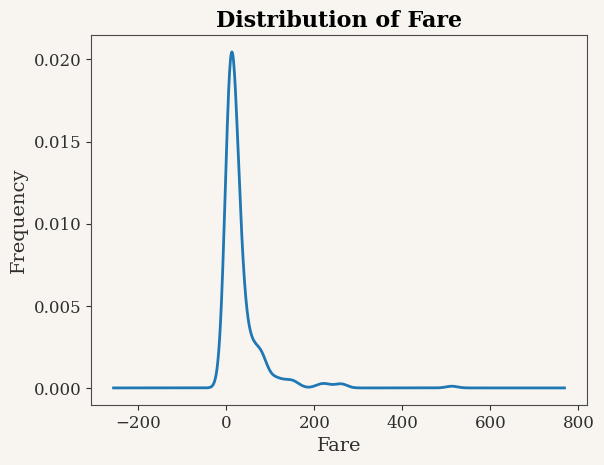

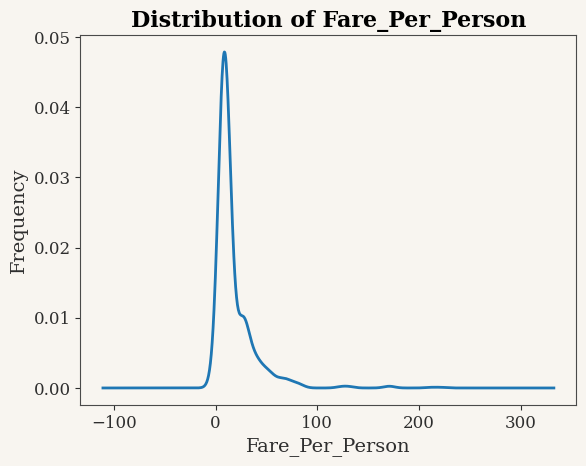

In [60]:
for column in ['Age','Fare','Fare_Per_Person']:
    ax=df[column].plot(kind='kde',title=f'Distribution of {column}')
    ax.set_xlabel(f'{column}')
    ax.set_ylabel('Frequency')
    plt.show()

<m>

### 1.5 Import to sql server

<m>

In [ ]:
df_sql = df.copy()
df_sql.columns = [c.replace(" ", "_").replace("-", "_") for c in df_sql.columns]

In [ ]:
server = r'DESKTOP-KHP38V4'
database = 'Titanic'
driver = 'ODBC Driver 17 for SQL Server'
conn_str = (
    f"mssql+pyodbc://@{server}/{database}"
    f"?driver={driver.replace(' ', '+')}"
    "&trusted_connection=yes")
engine = create_engine(conn_str)
df_sql.to_sql('titanic_table', engine, if_exists='replace', index=False)

<M>

## 2. Analyzing data

<m>

### 2.1 Heatmap

<m>

In [61]:
numeric_columns=df.select_dtypes(include='number')

In [62]:
cor1=numeric_columns.corr()
cor1

,PassengerId,Age,Family_Size,Pclass,Fare,Fare_Per_Person,Survived
PassengerId,1.000000,0.038488,-0.040143,-0.035144,0.012660,-0.002226,-0.005007
Age,0.038488,1.000000,-0.258195,-0.412127,0.122073,0.252265,-0.059305
Family_Size,-0.040143,-0.258195,1.000000,0.065997,0.217142,0.021702,0.016639
Pclass,-0.035144,-0.412127,0.065997,1.000000,-0.549496,-0.655557,-0.338481
Fare,0.012660,0.122073,0.217142,-0.549496,1.000000,0.839041,0.257305
Fare_Per_Person,-0.002226,0.252265,0.021702,-0.655557,0.839041,1.000000,0.254821
Survived,-0.005007,-0.059305,0.016639,-0.338481,0.257305,0.254821,1.000000


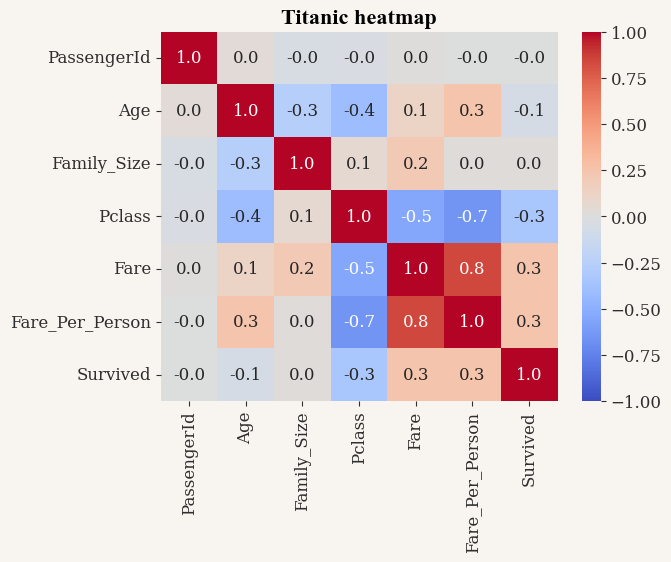

In [63]:
sns.heatmap(cor1,annot=True,center=0,vmin=-1,vmax=1,fmt='.1f',edgecolor='grey',cmap='coolwarm')
plt.title('Titanic heatmap',fontfamily='times new roman')
plt.show()

<m>

### 2.2 Relation between gender and survival

<m>

In [64]:
df_survived=df[df['Survived']==1]

,PassengerId,Name,Gender,Age,Family_Size,Pclass,Ticket,Fare,Fare_Per_Person,Survived
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,1,PC 17599,71.28,71.28,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,3,STON/O2. 3101282,7.92,7.92,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,1,113803,53.10,26.55,1
8,9,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,2,3,347742,11.13,3.71,1
9,10,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,2,237736,30.07,15.04,1
10,11,"Sandstrom, Miss. Marguerite Rut",female,4.0,2,3,PP 9549,16.70,8.35,1
11,12,"Bonnell, Miss. Elizabeth",female,58.0,0,1,113783,26.55,26.55,1
15,16,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,2,248706,16.00,16.00,1
17,18,"Williams, Mr. Charles Eugene",male,30.0,0,2,244373,13.00,13.00,1
19,20,"Masselmani, Mrs. Fatima",female,22.0,0,3,2649,7.22,7.22,1


In [72]:
gender_survived=df_survived.groupby('Gender')['Survived'].sum().sort_values(ascending=False)
gender_survived

Gender
female    233
male      109
Name: Survived, dtype: int64

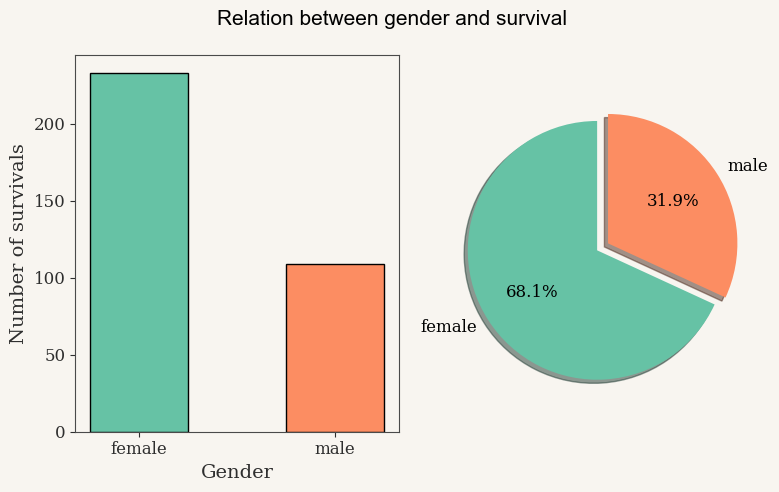

In [66]:
explode = [0.1 if v == gender_survived.max() else 0 for v in gender_survived.values]
colors = ['#66c2a5', '#fc8d62']
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(8,5))
axis[0].bar(gender_survived.index,gender_survived.values,width=0.5,edgecolor='k',color=colors)
axis[0].set_xlabel('Gender')
axis[0].set_ylabel('Number of survivals')
axis[1].pie(gender_survived.values,labels=gender_survived.index,autopct='%1.1f%%',startangle=90,explode=explode,colors=colors,shadow=True)
plt.suptitle('Relation between gender and survival',fontfamily='Arial',size=15)
plt.tight_layout()
plt.show()

<m>

### 2.3 Relation between class and survival

<m>

In [73]:
class_survival=df_survived.groupby('Pclass')['Survived'].sum().sort_values(ascending=False)
class_survival

Pclass
1    136
3    119
2     87
Name: Survived, dtype: int64

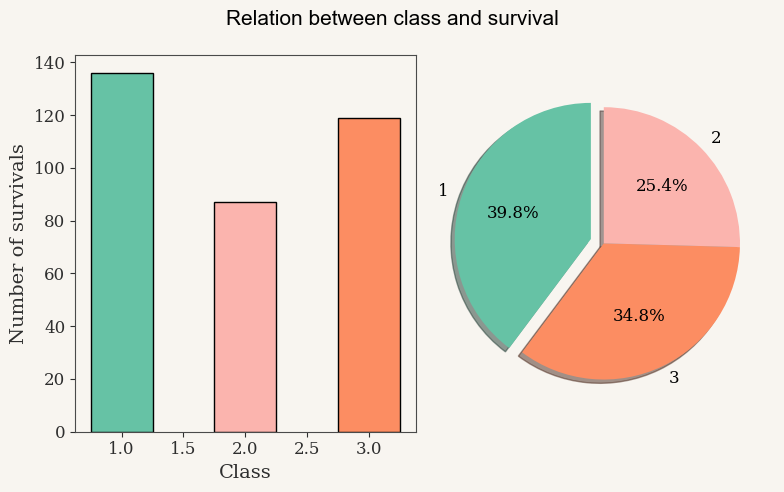

In [74]:
explode=[0.1 if v==class_survival.max() else 0 for v in class_survival.values]
colors=['#66c2a5', '#fc8d62','#fbb4ae']
fig,axis=plt.subplots(nrows=1,ncols=2,figsize=(8,5))
axis[0].bar(class_survival.index,class_survival.values,edgecolor='k',width=0.5,color=colors)
axis[0].set_xlabel('Class')
axis[0].set_ylabel('Number of survivals')
axis[1].pie(class_survival.values,labels=class_survival.index,autopct='%1.1f%%',explode=explode,colors=colors,shadow=True,startangle=90)
plt.suptitle('Relation between class and survival',fontfamily='Arial',size=15)
plt.tight_layout()
plt.show()

<m>

### 2.4 Relation between age and survived

<m>

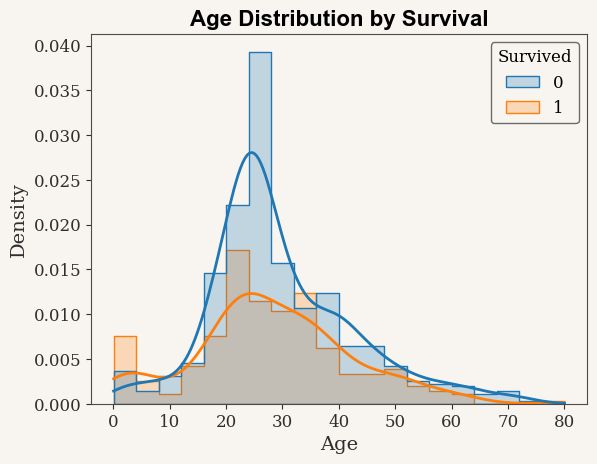

In [75]:
sns.histplot(data=df, x="Age", hue="Survived", bins=20, kde=True, element="step", stat="density")
plt.title("Age Distribution by Survival",fontfamily='arial')
plt.show()

<m>

### 2.5 Relation between family size and survival

<m>

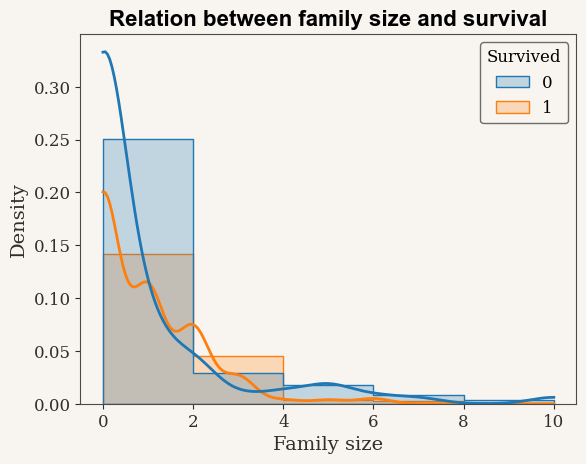

In [76]:
sns.histplot(data=df,x='Family_Size',hue='Survived',kde=True,bins=5,element='step',stat='density')
plt.title('Relation between family size and survival',fontfamily='arial')
plt.xlabel('Family size')
plt.show()

<m>

### 2.6 Relation between fare per person and survival

<m>

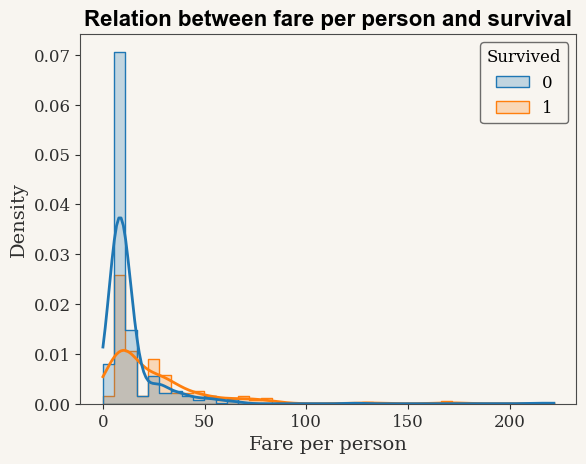

In [77]:
sns.histplot(data=df,x='Fare_Per_Person',hue='Survived',kde=True,bins=40,element='step',stat='density')
plt.title('Relation between fare per person and survival',fontfamily='arial')
plt.xlabel('Fare per person')
plt.show()

<m>